In [13]:
import pandas as pd
import seaborn as sns

In [14]:
df = pd.read_csv("/content/DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv")#Loading dataset

/tmp/ipykernel_16121/1097927350.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv")#Loading dataset


In [15]:
print(df.head())

        DESYNPUF_ID           PDE_ID   SRVC_DT PROD_SRVC_ID  QTY_DSPNSD_NUM  \
0  00013D2EFD8E45D1  233664490397622  20080103    247037252              30   
1  00013D2EFD8E45D1  233644490171972  20080105    223039502              10   
2  00013D2EFD8E45D1  233974489116848  20080109    364724812             120   
3  00013D2EFD8E45D1  233574491083209  20080123    179180672              30   
4  00013D2EFD8E45D1  233024491180571  20080124  58016005300              30   

   DAYS_SUPLY_NUM  PTNT_PAY_AMT  TOT_RX_CST_AMT  
0              20            10             120  
1              10             0               0  
2              30            10             110  
3              30             0             240  
4              30            70              70  


In [16]:
df['Patient_ID'] = df['DESYNPUF_ID'] # Pseudonymised patient/beneficiary identifier
df['Service_Date'] = df['SRVC_DT'] # Prescription fill/service date
df['Drug_ID'] = df['PROD_SRVC_ID'] # NDC-11 drug product code (the dispensed item)
df['Quantity_Dispensed'] = df['QTY_DSPNSD_NUM'] # Quantity dispensed
df['Expected_Duration'] = df['DAYS_SUPLY_NUM'] # Days of supply (expected duration of the fill)
df['Patient_Pay'] = df['PTNT_PAY_AMT'] # Patient pay amount (cost signal)
df['Total_Cost'] = df['TOT_RX_CST_AMT'] # Total drug cost (cost signal)

Column	Meaning
DESYNPUF_ID	Pseudonymised patient/beneficiary identifier
SRVC_DT	Prescription fill/service date
PROD_SRVC_ID	NDC-11 drug product code (the dispensed item)
DAYS_SUPLY_NUM	Days of supply (expected duration of the fill)
QTY_DSPNSD_NUM	Quantity dispensed
PTNT_PAY_AMT	Patient pay amount (cost signal)
TOT_RX_CST_AMT	Total drug cost (cost signal)

In [17]:
from datetime import datetime, timedelta

def convert_custom_date(date_str):
    date_str = str(date_str)
    year = int(date_str[:4])
    month = int(date_str[4:6])
    offset = int(date_str[6:])-1

    start = datetime(year, month, 1)
    return start + timedelta(days=offset)

# Convert the date format
df['Service_Date'] = df['Service_Date'].apply(convert_custom_date)
#print(df.head())

In [18]:
print("There are in total ", df['Patient_ID'].nunique(), " different patients.")
print("There are in total ", df['Drug_ID'].nunique(), " different drugs.")

There are in total  18932  different patients.
There are in total  283826  different drugs.


In [19]:
# Previous and next fills
df['Previous_Service_Date'] = df.groupby(['Patient_ID', 'Drug_ID'])['Service_Date'].shift(1)
df['Next_Service_Date'] = df.groupby(['Patient_ID', 'Drug_ID'])['Service_Date'].shift(-1)

In [20]:
#df_filtered = df[df['Next_Service_Date'].notnull()]
#print(df_filtered)

In [21]:
df_filtered = df[df['Previous_Service_Date'].notnull()]

In [22]:
df_filtered['Gap_Between_Fill'] = (df_filtered['Service_Date'] - df_filtered['Previous_Service_Date']).dt.days

/tmp/ipykernel_16121/4203593168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Gap_Between_Fill'] = (df_filtered['Service_Date'] - df_filtered['Previous_Service_Date']).dt.days


In [23]:
df_filtered['Refill'] = df_filtered['Previous_Service_Date'].notna()

/tmp/ipykernel_16121/2041437829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Refill'] = df_filtered['Previous_Service_Date'].notna()


In [24]:
Grace_Window = 7
df_filtered['Late_Refill'] = df_filtered['Gap_Between_Fill'] - df_filtered['Expected_Duration'] > Grace_Window
#print(df_new[249:255])

/tmp/ipykernel_16121/489627405.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Late_Refill'] = df_filtered['Gap_Between_Fill'] - df_filtered['Expected_Duration'] > Grace_Window


In [25]:
import numpy as np
#df_filtered['Stopped'] = np.where(df_filtered['Refill'] == False, True, False)
#print(df[249:255])

In [26]:
df_filtered['Stopped'] = df_filtered['Gap_Between_Fill'] > 3*df_filtered['Expected_Duration']

/tmp/ipykernel_16121/3007198043.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Stopped'] = df_filtered['Gap_Between_Fill'] > 3*df_filtered['Expected_Duration']


In [27]:
df_filtered['MPR'] = df_filtered['Expected_Duration'] / (df_filtered['Expected_Duration'] + df_filtered['Gap_Between_Fill'])
print(df_filtered)

              DESYNPUF_ID           PDE_ID   SRVC_DT PROD_SRVC_ID  \
250      0001FDD721E223DC  233414491631992  20091114    536358006   
389      00036A21B65B0206  233194493296561  20100306  49884065501   
4436     00271F7DF9C2B88A  233144491523557  20080814  59762432006   
4532     00271F7DF9C2B88A  233504491929383  20100328      6073178   
6132     00354528E7D3A756  233314493159292  20080811  65084025214   
...                   ...              ...       ...          ...   
1040203  2F8E50CC372D90D2  233904491799687  20100823    603331928   
1041772  2FA35FE49A5196B7  233444489344329  20091001  63629144601   
1044142  2FBFF472B8941DD7  233264493613105  20090413  58016068360   
1044334  2FC4164D17FDA58A  233154489363178  20100324  62559088007   
1047584  2FED8B85BA341ED4  233644491102989  20081013    157039910   

         QTY_DSPNSD_NUM  DAYS_SUPLY_NUM  PTNT_PAY_AMT  TOT_RX_CST_AMT  \
250                  30              30             0               0   
389                  30  

/tmp/ipykernel_16121/2931622512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['MPR'] = df_filtered['Expected_Duration'] / (df_filtered['Expected_Duration'] + df_filtered['Gap_Between_Fill'])


In [28]:
cutoff_date = df_filtered['Service_Date'].quantile(0.8)

train = df_filtered[df_filtered['Service_Date'] <= cutoff_date]
valid = df_filtered[df_filtered['Service_Date'] > cutoff_date]

In [30]:
print(df_filtered)

              DESYNPUF_ID           PDE_ID   SRVC_DT PROD_SRVC_ID  \
250      0001FDD721E223DC  233414491631992  20091114    536358006   
389      00036A21B65B0206  233194493296561  20100306  49884065501   
4436     00271F7DF9C2B88A  233144491523557  20080814  59762432006   
4532     00271F7DF9C2B88A  233504491929383  20100328      6073178   
6132     00354528E7D3A756  233314493159292  20080811  65084025214   
...                   ...              ...       ...          ...   
1040203  2F8E50CC372D90D2  233904491799687  20100823    603331928   
1041772  2FA35FE49A5196B7  233444489344329  20091001  63629144601   
1044142  2FBFF472B8941DD7  233264493613105  20090413  58016068360   
1044334  2FC4164D17FDA58A  233154489363178  20100324  62559088007   
1047584  2FED8B85BA341ED4  233644491102989  20081013    157039910   

         QTY_DSPNSD_NUM  DAYS_SUPLY_NUM  PTNT_PAY_AMT  TOT_RX_CST_AMT  \
250                  30              30             0               0   
389                  30  

Top features:  Gap_Between_Fill    0.509893
Stopped             0.142860
Drug_ID             0.051372
dtype: float64
PR AUC: 1.0
AUC: 1.000


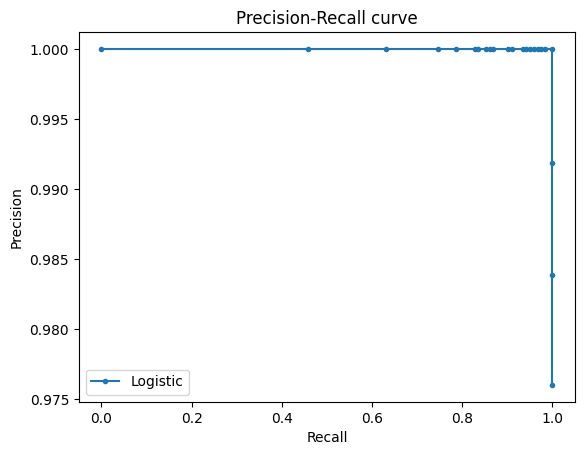

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

cutoff_date = df_filtered['Service_Date'].quantile(0.8)

train = df_filtered[df_filtered['Service_Date'] <= cutoff_date]
valid = df_filtered[df_filtered['Service_Date'] > cutoff_date]

X_train = train.drop(['Patient_ID','DESYNPUF_ID','Late_Refill','MPR','Previous_Service_Date','Next_Service_Date','Service_Date'],axis=1)
Y_train = train['Late_Refill']

X_valid = valid.drop(['Patient_ID','DESYNPUF_ID','Late_Refill','MPR','Previous_Service_Date','Next_Service_Date','Service_Date'],axis=1)
Y_valid = valid['Late_Refill']

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train,Y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top features: ",importances.head(3))

y_pred_proba = rf.predict_proba(X_valid)[:,1]

# Compute Precision and Recall for different thresholds.
precision, recall, thresholds = precision_recall_curve(Y_valid, y_pred_proba)

# Calculate Area Under the PR curve.
pr_auc = auc(recall, precision)

# Print the PR AUC
print(f'PR AUC: {pr_auc}')
print(f"AUC: {roc_auc_score(Y_valid, y_pred_proba):.3f}")
# Plot the Precision-Recall curve.
plt.plot(recall, precision, marker='.', label='Logistic')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()
